In [1]:
############ IMPORT LIBRARIES ############

from QNBAnalytics_ML import data
from QNBAnalytics_ML import skills_api
from QNBAnalytics_ML.feature_importances import plot_feature_importances
from QNBAnalytics_ML.param_grid_best import grids as param_grid_best
import pandas as pd
import numpy as np
import pickle
import datetime
import os
import time

version = "training"
start_time = datetime.datetime.now()

In [2]:
############ ENTER PARAMETERS ############

index_col = "MUQAVILE"  # index column
target_col = "TARGET"  # target column


## (OPTIONAL)

cols_to_drop = [
    "CC_O_4M6MWPS_EVER","ALL_O_4M6MWPS_EVER_O","ALL_O_7M12MWPS_EVER","ALL_O_7M12MWPS_EVER_O","ALL_OSMLMT_CWPS1_6_EVER",
    "CC_O_13M24MWPS_EVER","CC_O_13M24MWPS_EVER_O","CC_O_7M12MWPS_EVER","CC_O_7M12MWPS_EVER_O","CCOL_O_4M6MWPS_EVER",
    "CL_O_13M24MWPS_EVER_O","HL_EVERWPS_EVER","HL_O_13M24MWPS_365DP","HL_O_3MWPS_365DP","HL_O_4M6MWPS_EVER_O",
    "HL_O_7M12MWPS_EVER_O","HL_O_EVERWPS_365DP","OL_O_3MWPS_183D365D","OL_O_3MWPS_365DP","OL_O_4M6MWPS_183D365D",
    "OL_O_4M6MWPS_91D182D","OL_O_7M12MWPS_365DP","OL_O_EVERWPS_183D365D","OL_O_EVERWPS_365DP","OL_O_EVERWPS_90D",
    "OL_O_EVERWPS_91D182D","OL_OLMTUTL_CWPS0_90D_O","BGN",
############ columns that should not be used for training ############
    "ID", "FIN", "MKR_ID", "MKR_DATE", "IDS", "SCR_CONSTANT", "SCR_MULTIPLIER"
]


In [ ]:
############ TEMPORAL SPLIT CONFIGURATION ############
# 
# CRITICAL FIX: Use proper temporal split for credit scoring
# - Train: Earlier time period (model learns from past)
# - Test: Later time period (model predicts future)
# 
# This ensures realistic performance estimates and prevents distribution shift

USE_TEMPORAL_SPLIT = True  # Set to False to use old random split (not recommended!)

if USE_TEMPORAL_SPLIT:
    print("=" * 70)
    print("USING TEMPORAL TRAIN/TEST SPLIT")
    print("=" * 70)
    print("Train: 2018-01-01 to 2020-06-30 (historical data)")
    print("Test:  2020-07-01 to 2021-10-30 (future data)")
    print("This simulates real-world deployment: predict future from past")
    print("=" * 70)
else:
    print("WARNING: Using old random split - not recommended for production!")
    print("Expected: Train/Test distribution mismatch and overfitting")

In [ ]:
############ READ DATA WITH TEMPORAL SPLIT ############

if USE_TEMPORAL_SPLIT:
    # Use pre-created temporal split files
    print("\n[1/3] Loading temporal split data...")
    
    if os.path.exists('Data/data_train_temporal.csv') and os.path.exists('Data/data_test_temporal.csv'):
        print("Using pre-created temporal split files")
        data_train = pd.read_csv('Data/data_train_temporal.csv')
        data_test = pd.read_csv('Data/data_test_temporal.csv')
    else:
        print("Temporal files not found - creating split from full data...")
        # Load full data
        if os.path.exists('Data/data.csv'):
            data_full = pd.read_csv('Data/data.csv')
        else:
            data_full = pd.read_excel('Data/datamart_full.xlsx')
        
        # Create temporal split
        data_full['MKR_DATE'] = pd.to_datetime(data_full['MKR_DATE'])
        cutoff_date = pd.Timestamp('2020-07-01')
        data_train = data_full[data_full['MKR_DATE'] < cutoff_date].copy()
        data_test = data_full[data_full['MKR_DATE'] >= cutoff_date].copy()
        
        # Save for future use
        data_train.to_csv('Data/data_train_temporal.csv', index=False)
        data_test.to_csv('Data/data_test_temporal.csv', index=False)
        print("Saved temporal split files for future use")
    
    print(f"[OK] Train loaded: {data_train.shape}")
    print(f"[OK] Test loaded:  {data_test.shape}")

else:
    # Old method - simple split by row number (NOT RECOMMENDED!)
    print("\n[1/3] Loading data with simple row split (old method)...")
    
    if os.path.exists('Data/data.csv'):
        data_file = 'Data/data.csv'
        read_func = pd.read_csv
        print("Using CSV file")
    else:
        data_file = 'Data/datamart_full.xlsx'
        read_func = pd.read_excel
        print("Using Excel file")
    
    data_full = read_func(data_file)
    data_train = data_full.iloc[:85955].copy()
    data_test = data_full.iloc[85955:].copy()
    print(f"[OK] Train size: {data_train.shape}")
    print(f"[OK] Test size:  {data_test.shape}")

print("\n[2/3] Processing train data...")
# Remove rows with missing TARGET
missing_target_train = data_train[target_col].isna().sum()
if missing_target_train > 0:
    print(f"Removing {missing_target_train} rows with missing TARGET from train")
    data_train = data_train[data_train[target_col].notna()].copy()

# Set index and rename target
train = data_train.set_index(index_col).rename(columns={target_col: "TARGET"})
y_train = train["TARGET"]

# Verify no NaN in target
if y_train.isna().any():
    nan_count = y_train.isna().sum()
    print(f"WARNING: Found {nan_count} NaN values in y_train after processing - removing them")
    valid_mask = y_train.notna()
    y_train = y_train[valid_mask]
    train = train[valid_mask]

# Drop excluded columns
cols_to_drop_existing = [col for col in cols_to_drop if col in train.columns]
x_train = train.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)

print(f"[OK] Training features: {x_train.shape}")
print(f"[OK] Training default rate: {y_train.mean():.2%}")
if 'MKR_DATE' in data_train.columns:
    print(f"[OK] Training date range: {pd.to_datetime(data_train['MKR_DATE']).min()} to {pd.to_datetime(data_train['MKR_DATE']).max()}")

print("\n[3/3] Processing test data...")
# Remove rows with missing TARGET
missing_target_test = data_test[target_col].isna().sum()
if missing_target_test > 0:
    print(f"Removing {missing_target_test} rows with missing TARGET from test")
    data_test = data_test[data_test[target_col].notna()].copy()

# Set index and rename target
test = data_test.set_index(index_col).rename(columns={target_col: "TARGET"})
y_test = test["TARGET"]

# Verify no NaN in target
if y_test.isna().any():
    nan_count = y_test.isna().sum()
    print(f"WARNING: Found {nan_count} NaN values in y_test after processing - removing them")
    valid_mask = y_test.notna()
    y_test = y_test[valid_mask]
    test = test[valid_mask]

# Drop excluded columns
cols_to_drop_existing_test = [col for col in cols_to_drop if col in test.columns]
x_test = test.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)

print(f"[OK] Test features: {x_test.shape}")
print(f"[OK] Test default rate: {y_test.mean():.2%}")
if 'MKR_DATE' in data_test.columns:
    print(f"[OK] Test date range: {pd.to_datetime(data_test['MKR_DATE']).min()} to {pd.to_datetime(data_test['MKR_DATE']).max()}")

# Final validation
assert not y_train.isna().any(), "FATAL: y_train still has NaN values!"
assert not y_test.isna().any(), "FATAL: y_test still has NaN values!"

# Check for distribution mismatch
default_rate_diff = abs(y_train.mean() - y_test.mean())
if default_rate_diff > 0.01:  # More than 1% difference
    print(f"\nWARNING: Train/Test default rate difference: {default_rate_diff:.2%}")
    print("This may indicate distribution mismatch - consider reviewing split strategy")
else:
    print(f"\n[OK] Train/Test default rates are similar (difference: {default_rate_diff:.2%})")

print("\n" + "=" * 70)
print("DATA VALIDATION PASSED")
print("=" * 70)

In [5]:
## PIPELINE SETTINGS

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True      # BEFORE binning - correct!
apply_binning = True               # PRIMARY encoding method
apply_low_gini_elimination = True  # AFTER binning - correct!
apply_correlated_feature_elimination = True
apply_scaling = False
apply_categorical_encoding = False  # SET TO FALSE - binning handles it!

apply_LR = True

In [6]:
class Pipeline_Base:
    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding for ALL features)    ############################
        # THIS IS NOW THE PRIMARY ENCODING METHOD
        # Handles numeric (with binning first) + categorical (directly)

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # Now all features are WOE-encoded (numeric), so Gini can be calculated

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################

        if apply_scaling:
            self.pipeline.scaling()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_base'])


    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

2025-11-26 08:19:54,229 - qnbanalytics - INFO - There might be multiple ID in dataframe
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(

Fitting WOE encoding for 1579 variables using category_encoders.WOEEncoder...
Calculating Gini scores for all features...
WOE encoding fitted for 1579 variables


2025-11-26 08:23:10,332 - qnbanalytics - INFO - Opt binning completed... 
2025-11-26 08:23:15,733 - qnbanalytics - INFO - No ID detected!
2025-11-26 08:23:19,496 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 08:23:19,497 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 08:23:20,264 - qnbanalytics - INFO - Feature Elimination Started: drop_low_gini_features
2025-11-26 08:24:06,463 - qnbanalytics - INFO - Feature Elimination completed.
2025-11-26 08:24:06,952 - qnbanalytics - INFO - No ID detected!
2025-11-26 08:24:07,254 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 08:24:07,255 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 08:24:07,340 - qnbanalytics - INFO - Feature Elimination Started: correlated_lower_gini_feature_elimination
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\elimination.py:461: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-26 08:24:17,267 - qnbanalytics - INFO - Refitting to all data...


is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\base.py:1206: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:133: UserWarning: Model is linear, disabling fast option...
  warnings.warn("Model is linear, disabling fast option...") if fast else print("")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LogisticRegression(C=0.03726121757536122, multi_class='auto', random_state=48)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hu

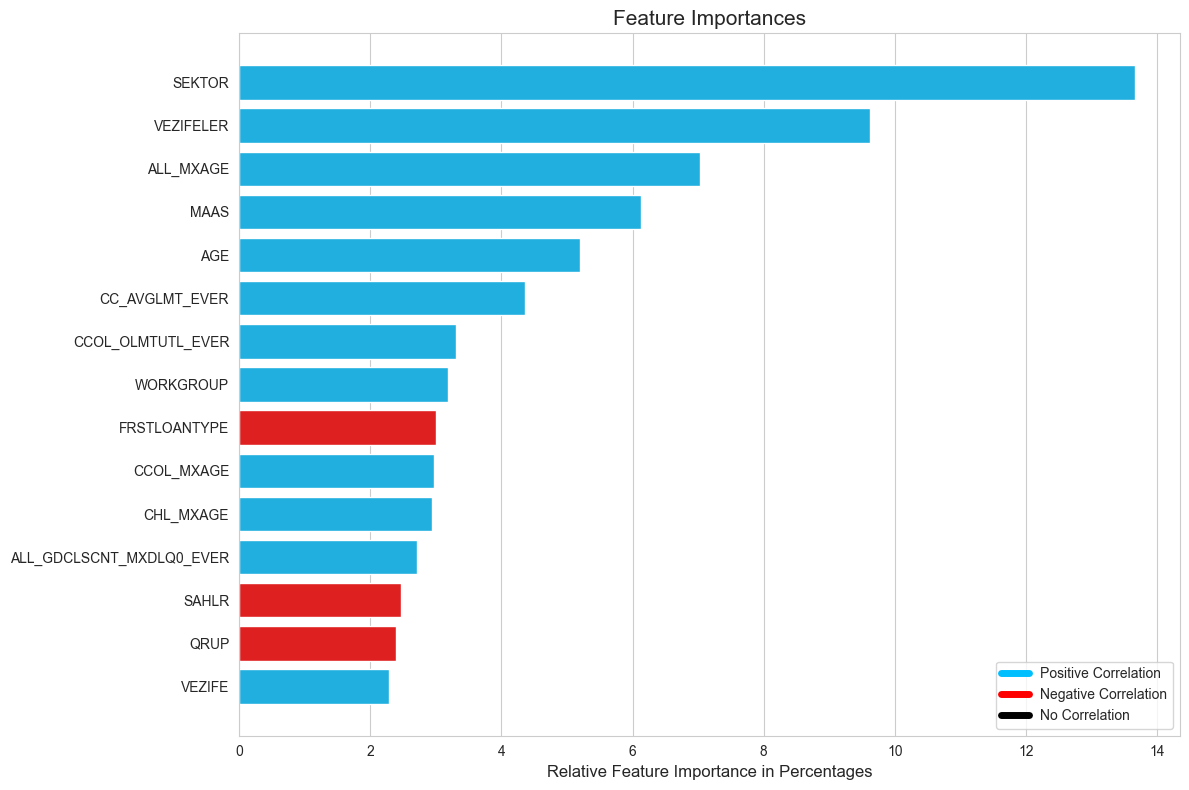

In [7]:
############ TRAIN MODEL ############

pipeline_base = Pipeline_Base()
pipeline_base.train(x_train = x_train, 
                    y_train = y_train,
                    x_test = x_test, 
                    y_test = y_test)

c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, palette=colors)


drop_null_eliminated_features: 911
drop_constant_eliminated_features: 224
low_gini_eliminated_features: 1424
correlation_elimination_eliminated_features: 89
used features: 66


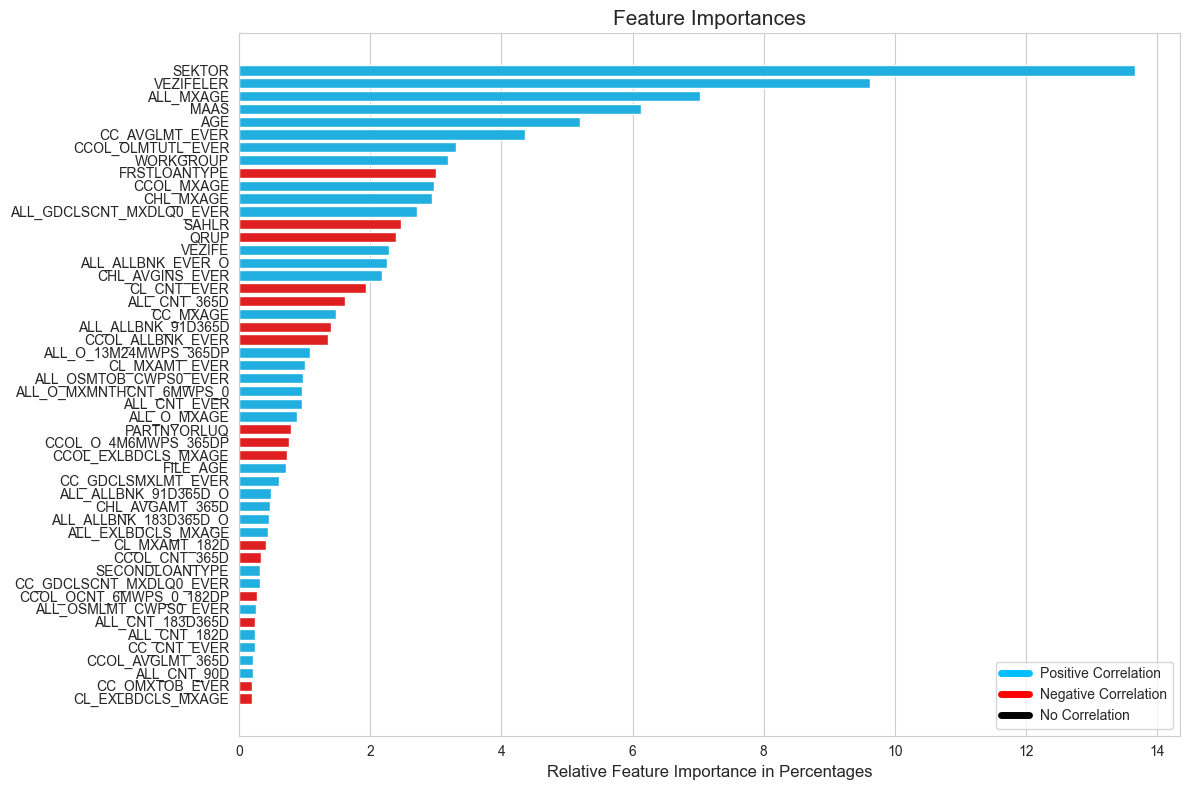

In [8]:
############ SAVE MODEL ############

model_path = f'Models/base_model_{version}.pkl'
with open(model_path, 'wb') as out:
    pickle.dump(pipeline_base.pipeline, out, pickle.HIGHEST_PROTOCOL)


############ LOAD MODEL ############

# model_path = f'Models/base_model_{version}.pkl'
# with open(model_path, 'rb') as f:
#   pipeline_base = pickle.load(f)


############ FEATURE IMPORTANCE ############
plot_feature_importances(df=pipeline_base.pipeline.logistic_regression_model.model.feature_importances,
                          n=50,
                          save_figure=True,
                          name_ext=f"Base_{version}")


feature_importances = pipeline_base.pipeline.logistic_regression_model.model.feature_importances
pd.DataFrame(feature_importances).to_excel(f"Output/FEATURE_IMPORTANCES_BASE_{version}.xlsx")



binning_table = pipeline_base.pipeline.monotonic_binning.get_binning_table()
pd.DataFrame(binning_table[0]).to_excel(f"Output/BINNING_TABLE_BASE_{version}.xlsx")
pd.DataFrame(binning_table[1]).to_excel(f"Output/GINI_TABLE_BASE_{version}.xlsx")





############ ELIMINATED FEATURES ############

variable_table = pipeline_base.pipeline.variable_table
pd.DataFrame(variable_table).to_excel(f"Output/FEATURES_BASE_{version}.xlsx")


drop_null_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_null_features']
drop_constant_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_constant_features']
low_gini_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_low_gini_features']
correlation_elimination_eliminated_features = pipeline_base.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(drop_null_eliminated_features, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(drop_constant_eliminated_features, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_BASE_{version}.xlsx")


print(
"""drop_null_eliminated_features: %d
drop_constant_eliminated_features: %d
low_gini_eliminated_features: %d
correlation_elimination_eliminated_features: %d
used features: %d""" % (len(drop_null_eliminated_features), len(drop_constant_eliminated_features), len(low_gini_eliminated_features), len(correlation_elimination_eliminated_features), sum(variable_table.use == True)))

In [9]:
############ PERFORMANCE OF THE BASE MODEL (LAYER_1) ############

############ BASIC PIPELINE RESULTS ############

base_test_proba_dict = pipeline_base.apply(x_test, y_test)
base_test_proba = base_test_proba_dict["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]

2025-11-26 08:24:47,276 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:24:47,475 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:24:47,659 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:24:47,669 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:24:52,202 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:24:52,203 - qnbanalytics - INFO - Train gini: 0.6304339993483057
2025-11-26 08:24:52,204 - qnbanalytics - INFO - CV gini: 0.6139512905989875
2025-11-26 08:24:52,205 - qnbanalytics - INFO - Valid gini: 0.382979988966198
2025-11-26 08:24:52,210 - qnbanalytics - INFO - Test gini: 0.382979988966198



In [10]:
############ CALCULATE CREDIT SCORES ############

all_x = pd.concat([x_train,x_test], axis = 0)
all_y = pd.concat([y_train,y_test], axis = 0)

# Get predictions and extract the result (self-contained)
result = pipeline_base.apply(all_x, all_y)
# Find the Logistic Regression key
lr_keys = [key for key in result.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(result.keys())}")
base_all_proba = result[lr_keys[0]][0]
base_all_proba = pd.DataFrame(base_all_proba, index = all_y.index)


ref=200
odds_at_ref=50
points_to_double=20


default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)



base_all_scores = pd.concat([base_all_proba, base_all_score, all_y], axis = 1)
base_all_scores.columns = ["PROBA","SCORE","TARGET"]
pd.DataFrame(base_all_scores).to_excel(f"Output/MAIN_SCORES_BASE_{version}.xlsx")

print("Base model took: %s" % (datetime.datetime.now()- start_time))

2025-11-26 08:25:04,236 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:25:06,390 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:25:07,488 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:25:07,538 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:25:34,544 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:25:34,546 - qnbanalytics - INFO - Train gini: 0.6304339993483057
2025-11-26 08:25:34,548 - qnbanalytics - INFO - CV gini: 0.6139512905989875
2025-11-26 08:25:34,549 - qnbanalytics - INFO - Valid gini: 0.382979988966198
2025-11-26 08:25:34,551 - qnbanalytics - INFO - Test gini: 0.592317982584738



Base model took: 0:06:21.830332


In [ ]:
############ LAYER 2 SETUP - WITH DATA LEAKAGE FIX ############

print("=" * 70)
print("LAYER 2 MODEL TRAINING - DATA LEAKAGE FIX APPLIED")
print("=" * 70)

# Score calibration parameters
ref = 200
odds_at_ref = 50
points_to_double = 20

good_score_threshold = 180  # goods: 180+ scores
not_good_score_threshold = 200  # not_goods: 200- scores
good_threshold = 1 / (np.exp((good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)
not_good_threshold = 1 / (np.exp((not_good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)

# CRITICAL FIX: Split x_train into train_base and validation
# This prevents data leakage in Layer 2 segment creation
from sklearn.model_selection import train_test_split

print("\n[1/4] Splitting training data for Layer 2...")
print("Creating train_base (80%) and validation (20%) sets")
print("Layer 2 segments will be created from VALIDATION set (no leakage!)")

x_train_base, x_val, y_train_base, y_val = train_test_split(
    x_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train  # Maintain default rate
)

train_base = train.loc[y_train_base.index]
val = train.loc[y_val.index]

print(f"[OK] Train_base: {x_train_base.shape[0]:,} samples, {y_train_base.mean():.2%} default rate")
print(f"[OK] Validation: {x_val.shape[0]:,} samples, {y_val.mean():.2%} default rate")

# Retrain base model on train_base ONLY (not full x_train!)
print("\n[2/4] Re-training base model on train_base (80% of training data)...")
print("This ensures Layer 2 segments are created without data leakage")

pipeline_base_for_layer2 = Pipeline_Base()
pipeline_base_for_layer2.train(x_train=x_train_base, y_train=y_train_base,
                               x_test=x_test, y_test=y_test)

# Get predictions on VALIDATION set (NO LEAKAGE!)
print("\n[3/4] Creating Layer 2 segments from validation set...")
val_preds = pipeline_base_for_layer2.apply(x_val, y_val)
lr_keys = [key for key in val_preds.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(val_preds.keys())}")
lr_key = lr_keys[0]

not_good_indices = val_preds[lr_key][0] >= not_good_threshold
good_indices = val_preds[lr_key][0] < good_threshold

print(f"[OK] Not Good segment: {not_good_indices.sum():,} samples")
print(f"[OK] Good segment: {good_indices.sum():,} samples")

# Create Layer 2 training sets from VALIDATION split
val_not_good = val[not_good_indices]
val_good = val[good_indices]

y_train_not_good = val_not_good["TARGET"]
y_train_good = val_good["TARGET"]

cols_to_drop_existing = [col for col in cols_to_drop if col in val_not_good.columns]
x_train_not_good = val_not_good.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)
x_train_good = val_good.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)

print("\nNot Good split (from validation set - no leakage):")
print(pd.concat([val_not_good.TARGET.value_counts(), 
                 val_not_good.TARGET.value_counts(normalize=True)], axis=1))
print("\nGood split (from validation set - no leakage):")
print(pd.concat([val_good.TARGET.value_counts(), 
                 val_good.TARGET.value_counts(normalize=True)], axis=1))

# Create test segments using base model predictions
print("\n[4/4] Creating Layer 2 test segments...")
test_preds = pipeline_base_for_layer2.apply(x_test=x_test, y_test=y_test)
lr_keys = [key for key in test_preds.keys() if "Logistic Regression" in key]
lr_key = lr_keys[0]

not_good_indices_test = test_preds[lr_key][0] >= not_good_threshold
good_indices_test = test_preds[lr_key][0] < good_threshold

test_not_good = test[not_good_indices_test]
test_good = test[good_indices_test]

y_test_not_good = test_not_good["TARGET"]
y_test_good = test_good["TARGET"]

cols_to_drop_existing_test = [col for col in cols_to_drop if col in test_not_good.columns]
x_test_not_good = test_not_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)
x_test_good = test_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)

print(f"[OK] Test Not Good: {x_test_not_good.shape[0]:,} samples")
print(f"[OK] Test Good: {x_test_good.shape[0]:,} samples")

print("\n" + "=" * 70)
print("LAYER 2 SETUP COMPLETE - DATA LEAKAGE ELIMINATED")
print("=" * 70)
print("Expected: Layer 2 models will have POSITIVE CV Gini scores")
print("Expected: Layer 2 test performance will be much better")
print("=" * 70)

In [12]:
############ CREATE PIPELINE FOR LAYER_2 MODELS ############

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True          # BEFORE binning
apply_binning = True                   # PRIMARY encoding method
apply_low_gini_elimination = True      # AFTER binning
apply_correlated_feature_elimination = True
apply_scaling = False                  # For Layer 1 (Base)
apply_categorical_encoding = False     # SKIP - binning handles encoding!
apply_scaling = True
apply_LR = True
apply_RF = True   # Layer 2 only
apply_XGB = True  # Layer 2 only
apply_LGBM = True # Layer 2 only

In [13]:
class Pipeline_Not_Good:
    """
    Not Good segment pipeline - SAME ORDER as Base
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################
        # BEFORE binning

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding)    ############################
        # PRIMARY encoding - BEFORE elimination

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # AFTER binning

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################
        # For Layer 2, scaling is typically enabled

        if apply_scaling:
            self.pipeline.scaling()


        ########################   Categorical Encoding    ############################
        # SKIP - binning handles it

        # if apply_categorical_encoding and not apply_binning:
        #     self.pipeline.encode_categoricals()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_not_good'])

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_not_good'])

        #########################        XGBoost          #############################

        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_not_good'])

        #########################      LGBM      #############################

        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_not_good'])

    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

In [14]:

class Pipeline_Good:
    """
    Good segment pipeline - SAME ORDER as Base
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################
        # BEFORE binning

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding)    ############################
        # PRIMARY encoding - BEFORE elimination

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # AFTER binning

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################
        # For Layer 2, scaling is typically enabled

        if apply_scaling:
            self.pipeline.scaling()


        ########################   Categorical Encoding    ############################
        # SKIP - binning handles it

        # if apply_categorical_encoding and not apply_binning:
        #     self.pipeline.encode_categoricals()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_good'])

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_good'])

        #########################        XGBoost          #############################

        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_good'])

        #########################      LGBM      #############################

        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_good'])

    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts


2025-11-26 08:26:17,552 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:26:17,778 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:26:18,005 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:26:18,015 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:26:23,452 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:26:23,454 - qnbanalytics - INFO - Train gini: 0.6304339993483057
2025-11-26 08:26:23,455 - qnbanalytics - INFO - CV gini: 0.6139512905989875
2025-11-26 08:26:23,455 - qnbanalytics - INFO - Valid gini: 0.382979988966198
2025-11-26 08:26:23,457 - qnbanalytics - INFO - Test gini: 0.382979988966198

2025-11-26 08:26:29,613 - qnbanalytics - INFO - There might be multiple ID in dataframe
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\iasamadov\D

Fitting WOE encoding for 1599 variables using category_encoders.WOEEncoder...
Calculating Gini scores for all features...
WOE encoding fitted for 1599 variables


2025-11-26 08:27:58,675 - qnbanalytics - INFO - Opt binning completed... 
2025-11-26 08:28:01,797 - qnbanalytics - INFO - No ID detected!
2025-11-26 08:28:02,993 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 08:28:02,994 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 08:28:03,608 - qnbanalytics - INFO - Feature Elimination Started: drop_low_gini_features
2025-11-26 08:28:18,039 - qnbanalytics - INFO - Feature Elimination completed.
2025-11-26 08:28:18,167 - qnbanalytics - INFO - No ID detected!
2025-11-26 08:28:18,233 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 08:28:18,234 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 08:28:18,262 - qnbanalytics - INFO - Feature Elimination Started: correlated_lower_gini_feature_elimination
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\elimination.py:461: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-26 08:28:19,794 - qnbanalytics - INFO - Refitting to all data...
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\base.py:1206: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LGBMClassifier(colsample_bytree=0.8, early_stopping_round=10,
               first_metric_only=True, max_depth=6, min_child_samples=370,
               n_estimators=10000, n_jobs=1, num_leaves=12, random_state=48,
               reg_alpha=1.7786201857096935e-08,
               reg_lambda=0.0003320897385975011, silent='warn', subsample=0.9,
               subsample_freq=1)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\shap\

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 08:34:40,533 - qnbanalytics - INFO - No ID detected!


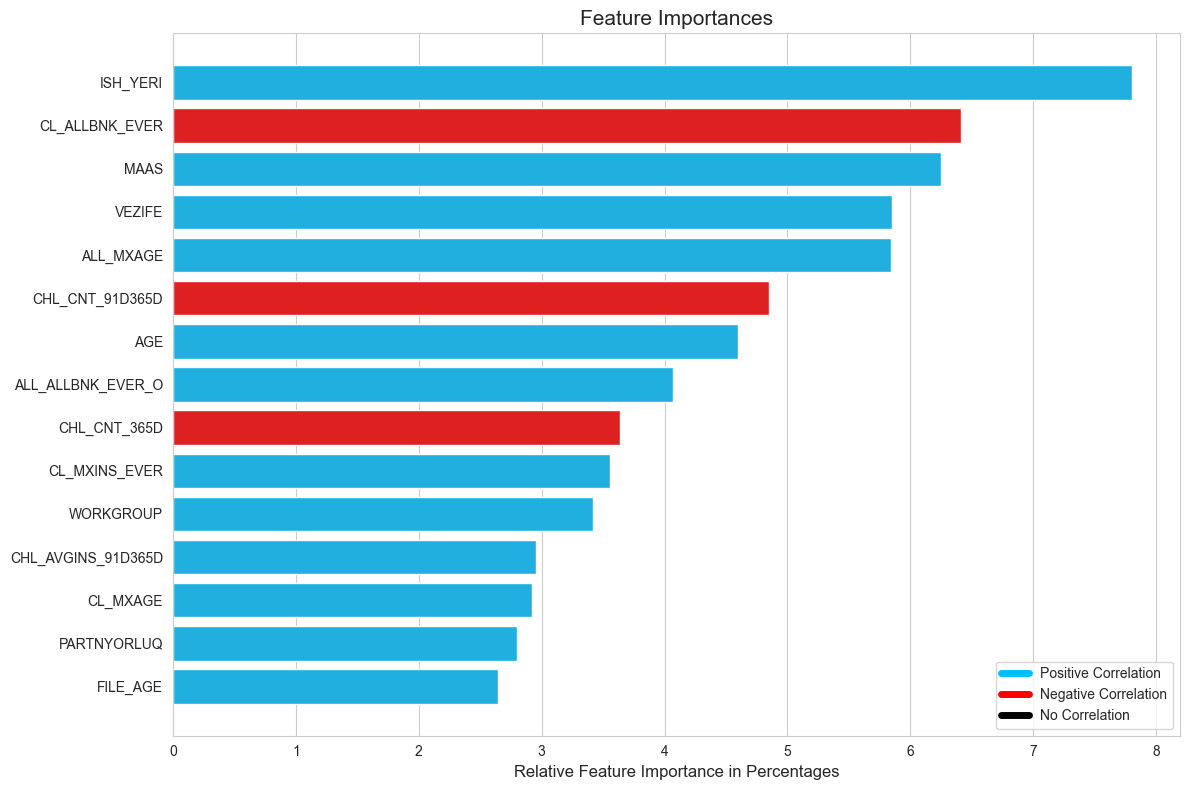

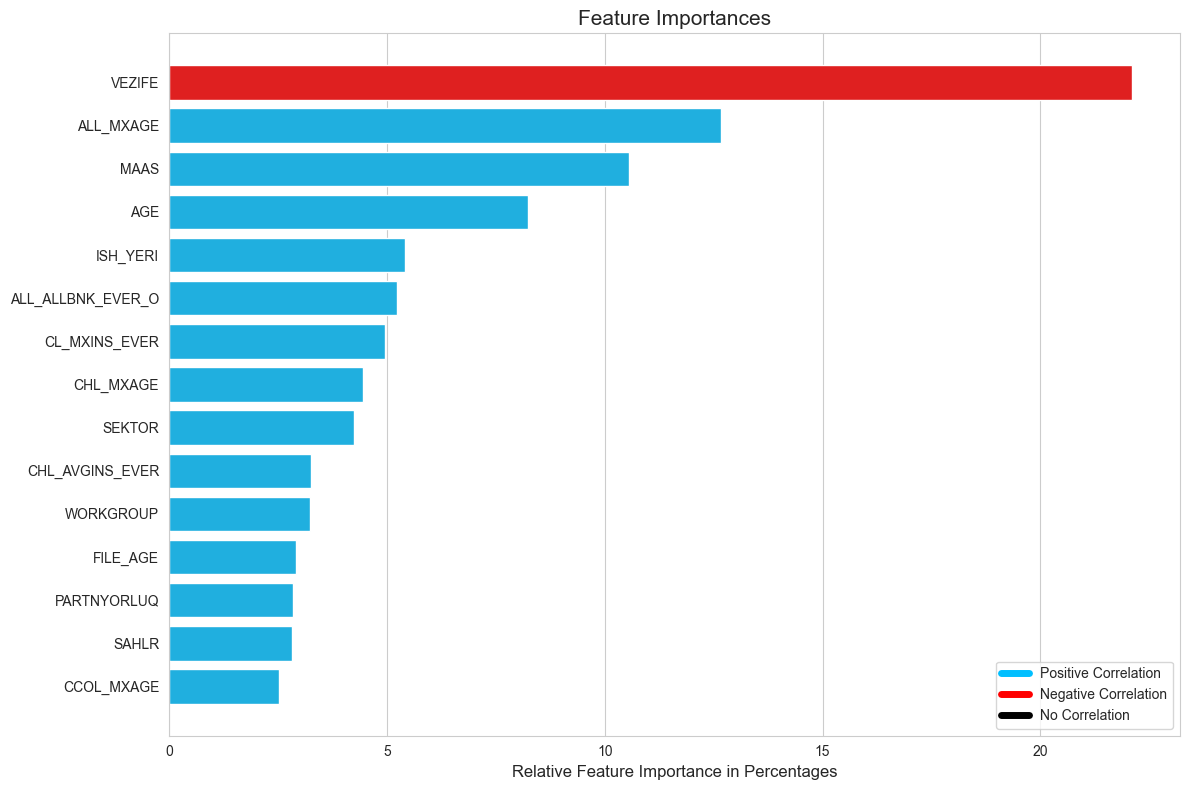

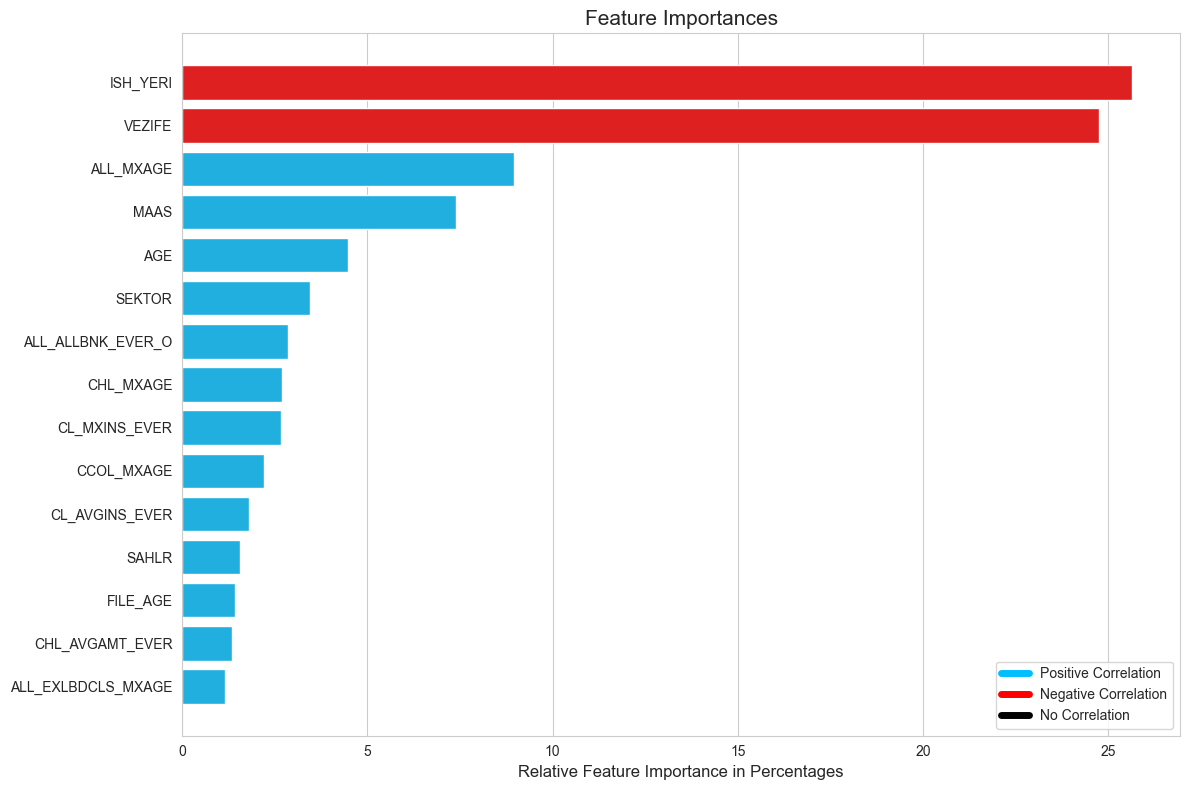

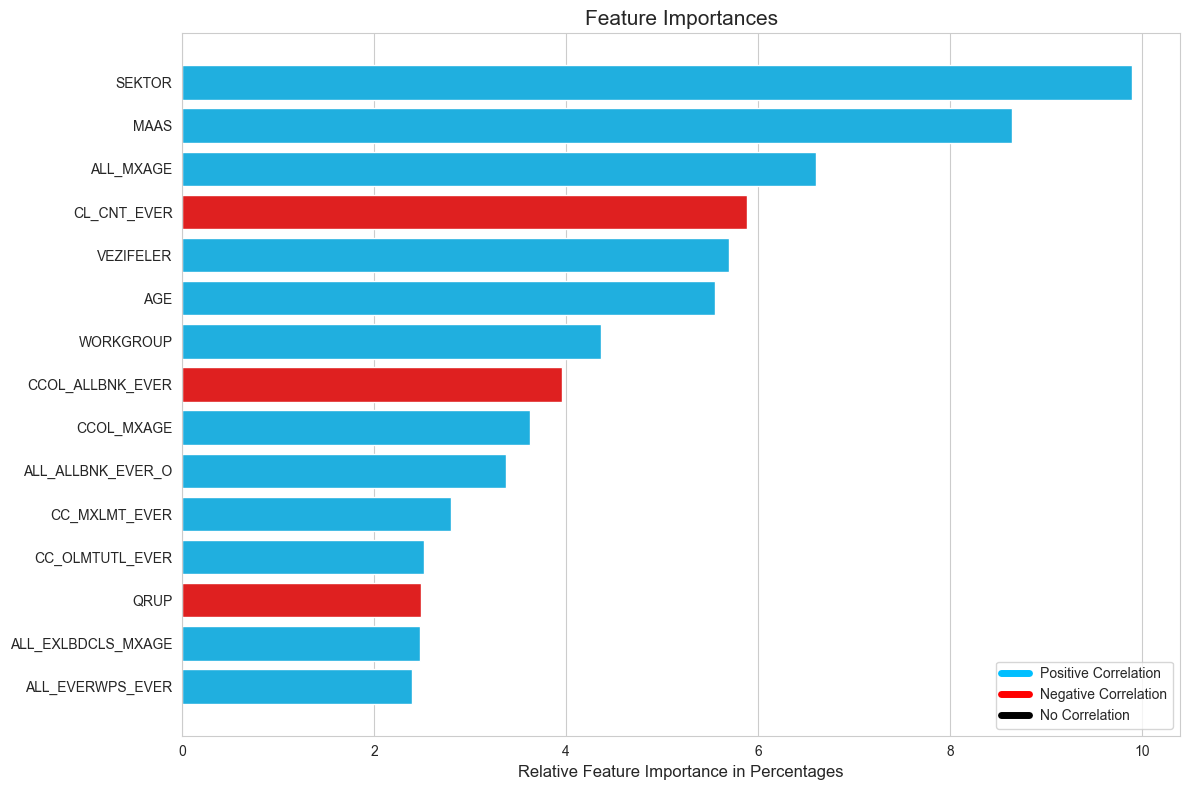

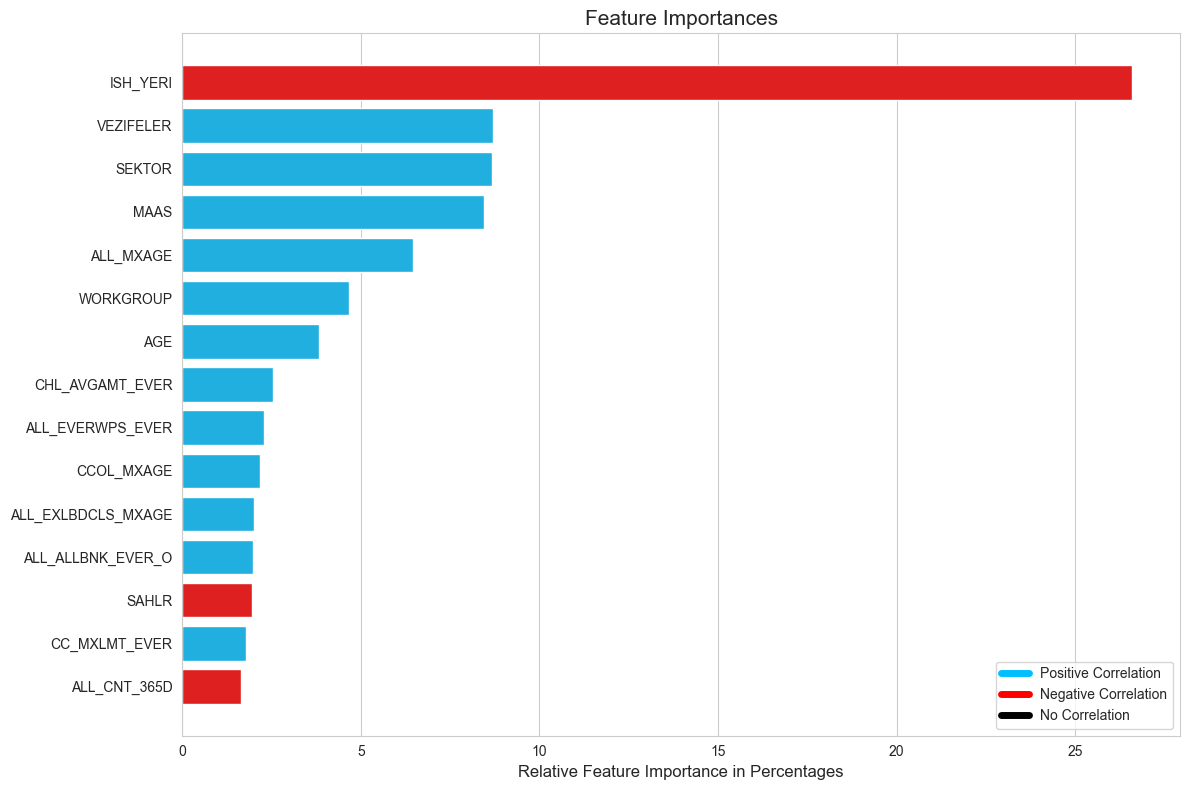

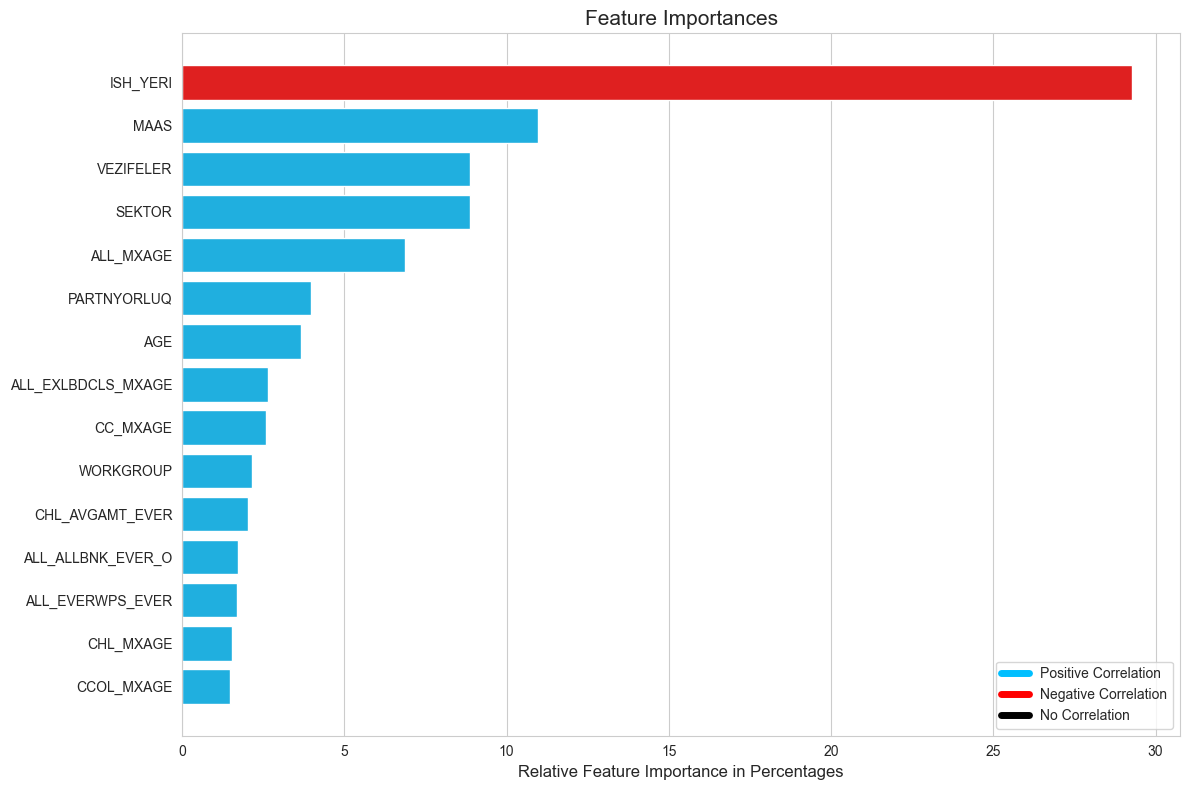

In [15]:
############ CREATE TEST DATA FOR LAYER_2 MODELS ############
# Get predictions (self-contained)
test_preds = pipeline_base.apply(x_test = x_test, y_test = y_test)
lr_keys = [key for key in test_preds.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(test_preds.keys())}")
lr_key = lr_keys[0]
not_good_indices_test = test_preds[lr_key][0] >= not_good_threshold
good_indices_test = test_preds[lr_key][0] < good_threshold

test_not_good = test[not_good_indices_test]
test_good = test[good_indices_test]

y_test_not_good = test_not_good["TARGET"]
y_test_good = test_good["TARGET"]

# Only drop columns that exist (safer approach)
cols_to_drop_existing_test = [col for col in cols_to_drop if col in test_not_good.columns]
x_test_not_good = test_not_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)
x_test_good = test_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)

############ TRAIN LAYER_2 MODELS ############

pipeline_not_good = Pipeline_Not_Good()
pipeline_not_good.train(x_train=x_train_not_good, y_train=y_train_not_good, x_test = x_test_not_good, y_test = y_test_not_good)

pipeline_good = Pipeline_Good()
pipeline_good.train(x_train=x_train_good, y_train=y_train_good, x_test = x_test_good, y_test = y_test_good)

In [16]:
############ SELECT BEST MODELS FOR LAYER_2 ############

pipeline_not_good.apply(x_test_not_good, y_test_not_good)
pipeline_good.apply(x_test_good, y_test_good)


2025-11-26 08:34:41,783 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:34:41,839 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:34:41,918 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:34:41,922 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:34:44,143 - qnbanalytics - INFO - Scaling started...

2025-11-26 08:34:44,154 - qnbanalytics - INFO - Scaling completed.

2025-11-26 08:34:44,169 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:34:44,170 - qnbanalytics - INFO - Train gini: 0.46224469180773875
2025-11-26 08:34:44,171 - qnbanalytics - INFO - CV gini: 0.4172530256433964
2025-11-26 08:34:44,173 - qnbanalytics - INFO - Valid gini: 0.12282753008694147
2025-11-26 08:34:44,175 - qnbanalytics - INFO - Test gini: 0.12282753008694147

2025-11-26 08:34:44,242 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 08:34:44,244 - qnbanalytics - INFO - Train gini: 0.7825491738

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 08:34:44,889 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:34:45,037 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:34:45,161 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:34:45,168 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:34:49,304 - qnbanalytics - INFO - Scaling started...

2025-11-26 08:34:49,311 - qnbanalytics - INFO - Scaling completed.

2025-11-26 08:34:49,322 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:34:49,323 - qnbanalytics - INFO - Train gini: 0.5717545045777248
2025-11-26 08:34:49,324 - qnbanalytics - INFO - CV gini: -1.0
2025-11-26 08:34:49,325 - qnbanalytics - INFO - Valid gini: 0.21039580109882983
2025-11-26 08:34:49,326 - qnbanalytics - INFO - Test gini: 0.21039580109882983

2025-11-26 08:34:49,460 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 08:34:49,460 - qnbanalytics - INFO - Train gini: 0.827236026231134
2025-11-2

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


{'15.Model: Logistic Regression': [array([0.00058146, 0.0082281 , 0.00409637, ..., 0.01113649, 0.01931497,
         0.00654256], shape=(9308,)),
  array([0, 0, 0, ..., 0, 0, 0], shape=(9308,))],
 '17.Model: Random Forest': [array([0.00387151, 0.00936427, 0.01151771, ..., 0.01328586, 0.03737842,
         0.00921055], shape=(9308,)),
  array([0, 0, 0, ..., 0, 0, 0], shape=(9308,))],
 '19.Model: XGBoost': [array([0.00098584, 0.00710071, 0.00354225, ..., 0.01050778, 0.03947554,
         0.0071433 ], shape=(9308,), dtype=float32),
  array([0, 0, 0, ..., 0, 0, 0], shape=(9308,))],
 '21.Model: LGBM': [array([0.00256559, 0.00662085, 0.00679566, ..., 0.02002126, 0.0843413 ,
         0.01395263], shape=(9308,)),
  array([0, 0, 0, ..., 0, 0, 0], shape=(9308,))]}

In [17]:
############ SAVE MODEL ############

model_path_not_good = f'Models/not_good_model_{version}.pkl'
model_path_good = f'Models/good_model_{version}.pkl'
with open(model_path_not_good, 'wb') as out:  pickle.dump(pipeline_not_good.pipeline, out, pickle.HIGHEST_PROTOCOL)
with open(model_path_good, 'wb') as out:  pickle.dump(pipeline_good.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [18]:
############ SELECTED MODELS ############

not_good_selected_model = 'Logistic Regression'
good_selected_model = 'LGBM'

not_good_model = 'logistic_regression'
good_model = 'lgbm'


In [19]:
############ FEATURE IMPORTANCES AND ELIMINATED FEATURES ############

feature_importances_not_good = getattr(pipeline_not_good.pipeline, f'{not_good_model}_model').model.feature_importances
feature_importances_good = getattr(pipeline_good.pipeline, f'{good_model}_model').model.feature_importances

pd.DataFrame(feature_importances_not_good).to_excel(f"Output/FEATURE_IMPORTANCES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(feature_importances_good).to_excel(f"Output/FEATURE_IMPORTANCES_GOOD_{version}.xlsx")

variable_table_not_good = pipeline_not_good.pipeline.variable_table
variable_table_good = pipeline_good.pipeline.variable_table
pd.DataFrame(variable_table_not_good).to_excel(f"Output/FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(variable_table_good).to_excel(f"Output/FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_null_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_null_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_constant_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_constant_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

low_gini_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_low_gini_features']
low_gini_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_low_gini_features']
pd.DataFrame(low_gini_eliminated_features_not_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

correlation_elimination_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
correlation_elimination_eliminated_features_good = pipeline_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(correlation_elimination_eliminated_features_not_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

In [ ]:
############ GENERATE FEATURES FOR LAYER_3 (META MODEL) ############

print("=" * 70)
print("GENERATING LAYER 3 FEATURES")
print("=" * 70)

# IMPORTANT: For Layer 3, we need to use the FULL training set
# We'll use the pipeline_base_for_layer2 model (trained on train_base)
# to generate features for the FULL training set

print("\n[1/2] Generating meta features for TRAINING set...")
print(f"Using full training set: {x_train.shape[0]:,} samples")

# Get base model predictions on FULL train set
base_train_proba_dict = pipeline_base_for_layer2.apply(x_train, y_train)
lr_keys = [key for key in base_train_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_train_proba_dict.keys())}")
base_train_proba = base_train_proba_dict[lr_keys[0]][0]

# Get Layer 2 model predictions on FULL train set
not_good_train_proba_dict = pipeline_not_good.apply(x_train, y_train)
ng_keys = [key for key in not_good_train_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_train_proba_dict.keys())}")
not_good_train_proba = not_good_train_proba_dict[ng_keys[0]][0]

good_train_proba_dict = pipeline_good.apply(x_train, y_train)
g_keys = [key for key in good_train_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_train_proba_dict.keys())}")
good_train_proba = good_train_proba_dict[g_keys[0]][0]

# Create meta features
base_train_proba = pd.DataFrame(base_train_proba, index=y_train.index)
not_good_train_proba = pd.DataFrame(not_good_train_proba, index=y_train.index)
good_train_proba = pd.DataFrame(good_train_proba, index=y_train.index)

x_train_meta = pd.concat([base_train_proba, good_train_proba, not_good_train_proba], axis=1)
x_train_meta.columns = ["Base", "Good", "Not_Good"]
y_train_meta = y_train

print(f"[OK] Train meta features: {x_train_meta.shape}")
print(f"[OK] Feature ranges:")
print(f"     Base: [{x_train_meta['Base'].min():.4f}, {x_train_meta['Base'].max():.4f}]")
print(f"     Good: [{x_train_meta['Good'].min():.4f}, {x_train_meta['Good'].max():.4f}]")
print(f"     Not_Good: [{x_train_meta['Not_Good'].min():.4f}, {x_train_meta['Not_Good'].max():.4f}]")

print("\n[2/2] Generating meta features for TEST set...")

# Get predictions on test set
base_test_proba_dict = pipeline_base_for_layer2.apply(x_test, y_test)
lr_keys = [key for key in base_test_proba_dict.keys() if "Logistic Regression" in key]
base_test_proba = base_test_proba_dict[lr_keys[0]][0]

not_good_test_proba_dict = pipeline_not_good.apply(x_test, y_test)
ng_keys = [key for key in not_good_test_proba_dict.keys() if f"{not_good_selected_model}" in key]
not_good_test_proba = not_good_test_proba_dict[ng_keys[0]][0]

good_test_proba_dict = pipeline_good.apply(x_test, y_test)
g_keys = [key for key in good_test_proba_dict.keys() if f"{good_selected_model}" in key]
good_test_proba = good_test_proba_dict[g_keys[0]][0]

# Create meta features
base_test_proba = pd.DataFrame(base_test_proba, index=y_test.index)
good_test_proba = pd.DataFrame(good_test_proba, index=y_test.index)
not_good_test_proba = pd.DataFrame(not_good_test_proba, index=y_test.index)

x_test_meta = pd.concat([base_test_proba, good_test_proba, not_good_test_proba], axis=1)
x_test_meta.columns = ["Base", "Good", "Not_Good"]
y_test_meta = y_test

print(f"[OK] Test meta features: {x_test_meta.shape}")
print(f"[OK] Feature ranges:")
print(f"     Base: [{x_test_meta['Base'].min():.4f}, {x_test_meta['Base'].max():.4f}]")
print(f"     Good: [{x_test_meta['Good'].min():.4f}, {x_test_meta['Good'].max():.4f}]")
print(f"     Not_Good: [{x_test_meta['Not_Good'].min():.4f}, {x_test_meta['Not_Good'].max():.4f}]")

print("\n" + "=" * 70)
print("LAYER 3 FEATURES GENERATED")
print("=" * 70)

In [21]:
############ CREATE PIPELINE AND TRAIN LAYER_3 MODEL ############

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True          # BEFORE binning
apply_binning = True                   # PRIMARY encoding method
apply_low_gini_elimination = True      # AFTER binning
apply_correlated_feature_elimination = True
apply_scaling = False                  # For Layer 1 (Base)
apply_categorical_encoding = False     # SKIP - binning handles encoding!

apply_LR = True

In [22]:

class Pipeline_Meta:
    """
    Meta model pipeline - No preprocessing needed, just model training
    Features are already probabilities from Layer 1 and Layer 2
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        # NO PREPROCESSING for meta model - features are already probabilities
        # Skip: null elimination, constant elimination, imputation, binning, elimination


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_meta'])


    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts



2025-11-26 08:37:01,902 - qnbanalytics - INFO - No ID detected!
2025-11-26 08:37:01,932 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 08:37:01,933 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 08:37:01,940 - qnbanalytics - INFO - 

2025-11-26 08:37:01,941 - qnbanalytics - INFO - Logistic Regression fitting started.

2025-11-26 08:37:01,944 - qnbanalytics - INFO - This is a binary classification problem.

2025-11-26 08:37:02,083 - qnbanalytics - INFO - Parameter optimization started.

c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=15. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will al

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-26 08:37:02,475 - qnbanalytics - INFO - Refitting to all data...
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-26 08:37:02,617 - qnbanalytics - INFO - Results of LogisticRegression(C=80.16389938139379, multi_class='auto', random_state=48)
2025-11-26 08:37:02,618 - qnbanalytics - INFO - Mean CV score:  0.7567930240157894
2025-11-26 08:37:02,620 - qnbanalytics - INFO - Calculating SHAP feature importances...
c:

is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:133: UserWarning: Model is linear, disabling fast option...
  warnings.warn("Model is linear, disabling fast option...") if fast else print("")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LogisticRegression(C=80.16389938139379, multi_class='auto', random_state=48)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hue`

is_classifier
is_classifier
is_classifier


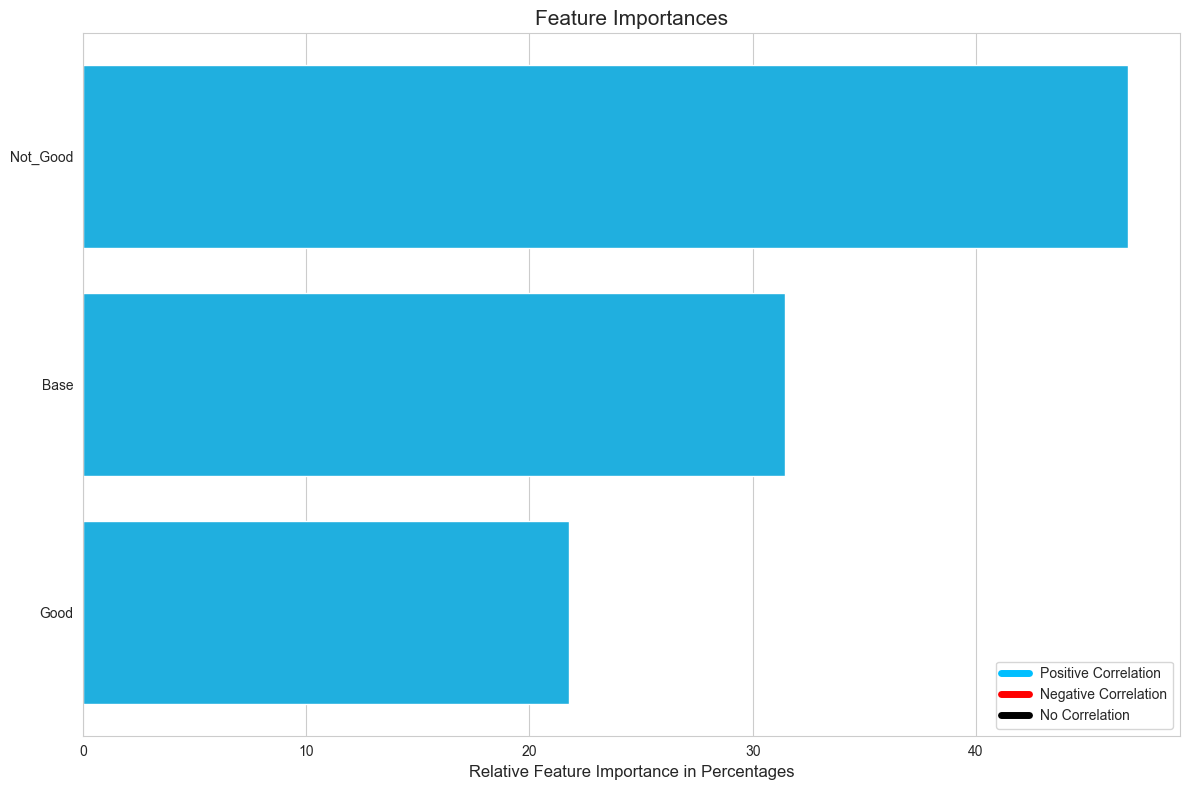

In [23]:
pipeline_meta = Pipeline_Meta()
pipeline_meta.train(x_train=x_train_meta, y_train=y_train_meta, x_test = x_test_meta, y_test = y_test_meta)

In [24]:
############ SAVE MODEL ############

model_path_meta = f'Models/meta_model_{version}.pkl'
with open(model_path_meta, 'wb') as out:
    pickle.dump(pipeline_meta.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [25]:
############ ADVANCED PIPELINE RESULTS ############

meta_test_proba_dict = pipeline_meta.apply(x_test_meta, y_test_meta)
meta_test_proba = meta_test_proba_dict["".join(key for key in meta_test_proba_dict if "Logistic Regression" in key)][0]
meta_test_proba = pd.DataFrame(meta_test_proba, index = y_test_meta.index)

2025-11-26 08:37:03,532 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:37:03,533 - qnbanalytics - INFO - Train gini: 0.755291662256315
2025-11-26 08:37:03,534 - qnbanalytics - INFO - CV gini: 0.7567930240157894
2025-11-26 08:37:03,535 - qnbanalytics - INFO - Valid gini: 0.3682865933359998
2025-11-26 08:37:03,536 - qnbanalytics - INFO - Test gini: 0.3682865933359998



In [26]:
############ APPLY TO ALL DATA ############

all_x = pd.concat([x_train,x_test], axis = 0)
all_y = pd.concat([y_train,y_test], axis = 0)

# Get predictions and extract results (self-contained)
base_all_proba_dict = pipeline_base.apply(all_x, all_y)
lr_keys = [key for key in base_all_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_all_proba_dict.keys())}")
base_all_proba = base_all_proba_dict[lr_keys[0]][0]

not_good_all_proba_dict = pipeline_not_good.apply(all_x, all_y)
ng_keys = [key for key in not_good_all_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_all_proba_dict.keys())}")
not_good_all_proba = not_good_all_proba_dict[ng_keys[0]][0]

good_all_proba_dict = pipeline_good.apply(all_x, all_y)
g_keys = [key for key in good_all_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_all_proba_dict.keys())}")
good_all_proba = good_all_proba_dict[g_keys[0]][0]

base_all_proba = pd.DataFrame(base_all_proba, index = all_y.index)
not_good_all_proba = pd.DataFrame(not_good_all_proba, index = all_y.index)
good_all_proba = pd.DataFrame(good_all_proba, index = all_y.index)

x_all_meta = pd.concat([base_all_proba,good_all_proba,not_good_all_proba], axis = 1)
x_all_meta.columns = ["Base","Good","Not_Good"]
y_all_meta = all_y

meta_all_proba_dict = pipeline_meta.apply(x_all_meta, y_all_meta)
lr_keys = [key for key in meta_all_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(meta_all_proba_dict.keys())}")
meta_all_proba = meta_all_proba_dict[lr_keys[0]][0]
meta_all_proba = pd.DataFrame(meta_all_proba, index = y_all_meta.index)




############ CALCULATE CREDIT SCORES ############

ref=200
odds_at_ref=100
points_to_double=20




default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)




default_rate = meta_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

meta_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
meta_all_score = pd.DataFrame(meta_all_score, index = all_y.index)





all_scores = pd.concat([base_all_proba, base_all_score, meta_all_proba, meta_all_score, all_y], axis = 1)
all_scores.columns = ["BASIC_PROBA","BASIC_SCORE","BOOSTED_PROBA","BOOSTED_SCORE","TARGET"]
pd.DataFrame(all_scores).to_excel(f"Output/MAIN_SCORES_{version}.xlsx")


print("Runtime: %s" % (datetime.datetime.now()- start_time))

2025-11-26 08:37:10,130 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:37:11,990 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:37:12,971 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:37:13,016 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:37:40,850 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:37:40,855 - qnbanalytics - INFO - Train gini: 0.6304339993483057
2025-11-26 08:37:40,857 - qnbanalytics - INFO - CV gini: 0.6139512905989875
2025-11-26 08:37:40,858 - qnbanalytics - INFO - Valid gini: 0.382979988966198
2025-11-26 08:37:40,859 - qnbanalytics - INFO - Test gini: 0.592317982584738

2025-11-26 08:37:46,588 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:37:48,492 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:37:49,427 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:37:49,470 - qnbanalytics - INF

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 08:38:20,440 - qnbanalytics - INFO - Results of LGBM
2025-11-26 08:38:20,442 - qnbanalytics - INFO - Train gini: 0.7938929423650865
2025-11-26 08:38:20,445 - qnbanalytics - INFO - CV gini: 0.664546664800451
2025-11-26 08:38:20,448 - qnbanalytics - INFO - Valid gini: 0.126724913272517
2025-11-26 08:38:20,452 - qnbanalytics - INFO - Test gini: 0.5837442152605608

2025-11-26 08:38:25,591 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:38:27,596 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:38:28,338 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 08:38:28,380 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 08:38:51,874 - qnbanalytics - INFO - Scaling started...

2025-11-26 08:38:51,893 - qnbanalytics - INFO - Scaling completed.

2025-11-26 08:38:51,967 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:38:51,967 - qnbanalytics - INFO - Train gini: 0.5717545045777248
2025-11

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 08:38:53,959 - qnbanalytics - INFO - Results of LGBM
2025-11-26 08:38:53,959 - qnbanalytics - INFO - Train gini: 0.8409803022282838
2025-11-26 08:38:53,960 - qnbanalytics - INFO - CV gini: -0.8660453893850478
2025-11-26 08:38:53,962 - qnbanalytics - INFO - Valid gini: 0.24737476026794414
2025-11-26 08:38:53,966 - qnbanalytics - INFO - Test gini: 0.7183537080972895

2025-11-26 08:38:54,039 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 08:38:54,040 - qnbanalytics - INFO - Train gini: 0.755291662256315
2025-11-26 08:38:54,040 - qnbanalytics - INFO - CV gini: 0.7567930240157894
2025-11-26 08:38:54,044 - qnbanalytics - INFO - Valid gini: 0.3682865933359998
2025-11-26 08:38:54,044 - qnbanalytics - INFO - Test gini: 0.6987830056996627



Runtime: 0:19:43.985965
